# (보충판) train_final_example + One-stage self-supervised (N2N through A + TV)

**이 노트북이 하는 일 (한 줄 요약)** : clean 정답을 loss 에 **한 번도 쓰지 않고**,
네트워크 하나가 "노이즈 제거 + deconvolution" 을 **한 방에** 배운다.

```
학습:   같은 blur 이미지에 독립 노이즈를 두 번 입힌 쌍 (y1, y2) 를 만들고

        loss = | A( f(y1) ) − y2 |   +   λ · TV( f(y1) )
                 └ 물리 일치 항 ┘         └ 매끈함 상식 항 ┘

추론:   test 이미지 → f → 복원 결과 끝. (Wiener 등 후처리 없음)
```

**loss 세 부품의 역할**
- `f(y1)` : 네트워크의 복원 추정 (clean 을 목표로 함)
- `A(·)` : 추정을 다시 dipole blur 시킴 → "네 답이 맞다면, 다시 blur 를 걸었을 때 관측과 같아야 한다"
  → **deconvolution 을 가르친다** (커널을 아니까 가능)
- 타깃이 y1 이 아니라 **y2** 인 이유 : y2 의 노이즈는 y1 과 독립이라 예측 불가능
  → 네트워크가 노이즈를 복원 결과에 남기면 손해 → **노이즈 제거를 가르친다** (Noise2Noise 원리)
- `TV` 항 : dipole 커널이 죽이는 주파수(cone)는 A 를 통과하면 사라져서 첫 항이 채점하지 못한다.
  그 사각지대를 "이미지는 조각조각 매끈해야 자연스럽다"는 상식으로 채운다.

**왜 이 구성인가** : 조교님이 Wiener filter 는 쓰지 않는 게 좋겠다고 하셨고,
트랙 목표가 self-supervised 이므로 deconv 까지 학습으로 해결한다.
clean label 사용 0회 → label-free 보너스 대상. λ 하나만 튜닝.

**규칙 준수** : orientation 은 공식 (0,1) 하나, 같은 blur 에 노이즈 이미지 2장(y1, y2)
→ "orientation 당 noisy 2장" 규칙의 한도 그대로.

**실행** : Run All 하면 이 트랙에 필요한 셀만 실행된다 (A/B 학습 호출은 raw 셀 처리).
체크포인트는 `logs_n2n/` 저장, 자동 이어걷기 지원. T4: batch 16 / A100: batch 64.

(참고: `train_final_nb2nb.ipynb` 는 two-stage 안이었고, 이 노트북이 그 후속 결정판이다)

# Dipole deconvolution + denoising restoration

0. 조교가 만든 A. end to end UNet network의 체크포인트를 제공해 드리오니, 필요 시 활용하셔도 됩니다.

1. dataset 폴더의 **test_deconv_noise** 데이터를 모델의 input으로 넣어서, **test_label(정답)** 데이터를 이용해 metric을 측정해 주세요.
test_deconv_noise dataset은 dipole conv --> noise 순서로 만들어 졌습니다.

2. metric을 측정을 위해 이전에 제공한 **psnr, ssim** 코드를 사용해 주세요.

**결과 분석 & 좋은 점수를 위한 tips...**
- test_deconv_noise/noise_meta.json 에서 각각의 이미지가 어떤 노이즈에 해당하는지 확인하실 수 있습니다. 결과 분석에만 사용해 주세요.

- train을 위해서 사용한 synthetic image, 결과 test 이미지는 꼭 visaulize 해 보세요. difference map, detail한 부분은 zoom-in을 해 주세요.

- 구축한 프레임워크가 어떤 노이즈에 취약한지, 어떤 type의 이미지에 취약한지 분석해 보세요.

- Day1, Day2 때 했던 conventional methods 들과 결과를 비교해 보세요.

- 적은 수의 데이터로 학습하기 or self supervised learning 방식을 활용해 보세요.

## 0. [보충] 설정 · 데이터 준비

배포본에 빠져 있는 import / 경로 / `config` 보충 (USRNet 트랙과 동일).
이 트랙은 체크포인트를 `logs_n2n/` 에 저장해 다른 트랙(`logs_final/`, `logs_nb2nb/`)과 분리한다.

In [1]:
import glob
import json
import os
import random
import time
import warnings
import zlib
from dataclasses import dataclass, field
from enum import Enum, IntEnum
from functools import lru_cache
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from torch.nn import functional
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---- 프로젝트 루트: Colab(Drive) 우선, 아니면 현재 폴더에서 위로 탐색 ----
ROOT = Path("/content/drive/MyDrive/플젝5")
if not ROOT.exists():
    try:
        from google.colab import drive  # Colab 인데 마운트가 안 된 경우

        drive.mount("/content/drive")
    except ImportError:
        ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "dataset").exists())
print(f"ROOT = {ROOT}")

# ---- Colab 이면 데이터셋을 VM 로컬 디스크로 복사 (Drive 직접 읽기는 I/O 병목) ----
# 이 노트북이 실제로 쓰는 폴더만 압축에서 선택적으로 푼다 (전체 unzip 은 test_* 폴더들까지 풀어 느리다).
# 학습 없이 평가만 할 때는 NEEDED_SPLITS 에서 "train" 을 빼면 수 초에 끝난다
# (단, 그 경우 공식 "2-1 Train synthetic pair 확인" 셀은 건너뛸 것).
NEEDED_SPLITS = ["train", "val", "test_label"]

if Path("/content").exists():
    import shutil
    import zipfile

    LOCAL_DATA = Path("/content/dataset")
    LOCAL_DATA.mkdir(parents=True, exist_ok=True)
    _zip = ROOT / "dataset.zip"
    _missing = [s for s in NEEDED_SPLITS if not (LOCAL_DATA / s).exists()]
    if _missing and _zip.exists():
        _t0 = time.time()
        with zipfile.ZipFile(_zip) as _zf:
            for _mname in _zf.namelist():
                if _mname.endswith("/"):
                    continue
                _parts = Path(_mname).parts
                if _parts and _parts[0] == "dataset":
                    _parts = _parts[1:]
                if not _parts or _parts[0] not in _missing:
                    continue
                _dest = LOCAL_DATA.joinpath(*_parts)
                _dest.parent.mkdir(parents=True, exist_ok=True)
                with _zf.open(_mname) as _srcf, open(_dest, "wb") as _outf:
                    shutil.copyfileobj(_srcf, _outf)
        print(f"unzip {_missing}: {time.time() - _t0:.1f}s")
    # zip 에 없는 폴더는 Drive 에서 복사 (이미 있으면 건너뜀)
    for _s in NEEDED_SPLITS:
        if not (LOCAL_DATA / _s).exists() and (ROOT / "dataset" / _s).exists():
            shutil.copytree(ROOT / "dataset" / _s, LOCAL_DATA / _s)
            print(f"sync {_s}")
    _d3 = ROOT / "test_deconv_noise" / "test_deconv_noise"
    if _d3.exists() and not (LOCAL_DATA / "test_deconv_noise").exists():
        shutil.copytree(_d3, LOCAL_DATA / "test_deconv_noise")
        print("sync test_deconv_noise")
    DATA_ROOT = LOCAL_DATA
else:
    DATA_ROOT = ROOT / "dataset"

# test measure 폴더 위치 (dataset/ 안 또는 프로젝트 루트의 배포 폴더)
TEST_MEASURE_DIR = DATA_ROOT / "test_deconv_noise"
if not TEST_MEASURE_DIR.exists():
    TEST_MEASURE_DIR = ROOT / "test_deconv_noise" / "test_deconv_noise"
print(f"DATA_ROOT = {DATA_ROOT}")
print(f"TEST_MEASURE_DIR = {TEST_MEASURE_DIR}")

# ---- 공식 셀들이 참조하는 상수 ----
VOXEL_SIZE: tuple[float, float] = (1.0, 1.0)
B0_DIR: tuple[float, float] = (0.0, 1.0)

NOISE_RANGES: dict[str, tuple[float, float]] = {
    "gaussian": (0.0, 0.1),
    "rician": (0.0, 0.15),
    "uniform": (0.0, 0.2),
    "salt_and_pepper": (0.0, 0.2),
}


@dataclass
class Config:
    train_split: str = "train"
    valid_split: str = "val"
    test_label_split: str = "test_label"

    valid_batch: int = 4
    num_workers: int = 2  # Colab 공유메모리(/dev/shm) 고갈 방지. 데이터 생성이 가벼워 2로 충분
    clip_output: bool = True  # finalize(): label 이 [0,1] 이므로 출력을 clip

    run_dir: Path = None  # 아래에서 설정
    usrnet_dir: Path = None
    device: torch.device = None


config = Config()
config.run_dir = ROOT / "logs_n2n"  # one-stage 트랙 전용 (다른 트랙과 분리)
config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {config.device}")

Mounted at /content/drive
ROOT = /content/drive/MyDrive/플젝5
unzip ['train', 'val', 'test_label']: 126.5s
sync test_deconv_noise
DATA_ROOT = /content/dataset
TEST_MEASURE_DIR = /content/dataset/test_deconv_noise
device = cuda


## 1. Forward model : dipole convolution + noise

$$y = \mathcal{N}\big(\underbrace{\mathcal{F}^{-1}\{D(k)\,\mathcal{F}\{x\}\}}_{\text{dipole convolution}}\big)$$

- `train` / `val` : clean image에 ** dipole + noise** 를 건다.
  - train 은 flip augmentation 후 매번 새 noise
  - val 은 파일 이름 기반 seed 로 noise 를 고정해 epoch 간 비교가 가능하게 한다
- `test` : 제공된 **`test_deconv_noise`**


### 1-1. Dipole kernel

$$D(k) = \frac{1}{3} - \frac{(k \cdot \hat{B_0})^2}{|k|^2}$$

`B0_dir = (0, 1)` -> magic angle (약 54.7도) 원뿔에서 `D = 0` 이라 그 성분은 원리적으로 복원 불가능하다.

In [2]:
@lru_cache(maxsize=16)
def dipole_kernel(
    matrix_size: tuple[int, int],
    voxel_size: tuple[float, float] = VOXEL_SIZE,
    B0_dir: tuple[float, float] = B0_DIR,
) -> torch.Tensor:
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)

    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])

    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    D = np.fft.fftshift(D)
    return torch.tensor(D, dtype=torch.float32)


def dipole_forward(img: Tensor) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel, dim=(-2, -1)).real


dipole_adjoint = dipole_forward  # A^T = A (D 가 real, even)

_D = dipole_kernel((256, 256))
print(f"D range [{_D.min():.4f}, {_D.max():.4f}] | |D| < 0.01 인 비율 {float((_D.abs() < 0.01).float().mean()) * 100:.2f}%")

D range [-0.6667, 0.3333] | |D| < 0.01 인 비율 1.59%


### 1-2. Noise 4종 (Gaussian, Rician, Uniform, Salt and Pepper)

    "gaussian": (0.0, 0.1),
    "rician": (0.0, 0.15),
    "uniform": (0.0, 0.2),
    "salt_and_pepper": (0.0, 0.2)

In [3]:
class NoisyType(str, Enum):
    Gaussian = "gaussian"
    Rician = "rician"
    Uniform = "uniform"
    SaltAndPepper = "salt_and_pepper"

    @classmethod
    def from_string(cls, value: str) -> "NoisyType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid NoisyType value: {value}. Must be one of {list(cls)} : {err}") from err

Gen = torch.Generator | None


def gaussian_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return img + noise


def rician_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise_real = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    noise_imag = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return torch.abs(img + noise_real + 1j * noise_imag)


def uniform_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    return img + (torch.empty_like(img).uniform_(0.0, 1.0, generator=generator) * 2.0 - 1.0) * sigma


def salt_and_pepper_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    salt_prob = sigma / 2
    pepper_prob = sigma / 2
    noisy_img = img.clone()
    total_pixels = img.numel()

    num_salt = int(total_pixels * salt_prob)
    coords = [torch.randint(0, dim, (num_salt,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = img.max()

    num_pepper = int(total_pixels * pepper_prob)
    coords = [torch.randint(0, dim, (num_pepper,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = 0

    return noisy_img


NOISE_FUNC: dict[NoisyType, Callable[..., Tensor]] = {
    NoisyType.Gaussian: gaussian_noise,
    NoisyType.Rician: rician_noise,
    NoisyType.Uniform: uniform_noise,
    NoisyType.SaltAndPepper: salt_and_pepper_noise,
}


class NoiseSimulator:
    """noise 종류 하나 + sigma 하나를 고정해서 적용한다."""

    def __init__(self, noisy_type: NoisyType, sigma: float) -> None:
        self.noisy_type = noisy_type
        self.sigma = sigma

    def __call__(self, img: Tensor, generator: Gen = None) -> Tensor:
        return NOISE_FUNC[self.noisy_type](img, self.sigma, generator)


class RandomNoiseSimulator:
    """이미지마다 4종 중 하나를 랜덤으로 골라 NOISE_RANGES 범위에서 sigma 를 뽑는다."""

    def __init__(self, noise_ranges: dict[str, tuple[float, float]] | None = None) -> None:
        self.noise_ranges = dict(noise_ranges) if noise_ranges is not None else dict(NOISE_RANGES)
        self.names = list(self.noise_ranges.keys())

    def _sample(self, rng) -> tuple[str, float]:
        name = rng.choice(self.names)
        low, high = self.noise_ranges[name]
        return name, rng.uniform(low, high)

    def __call__(self, img: Tensor, seed: int | None = None) -> Tensor:
        if seed is None:
            # 학습용: 매번 새로 뽑는다 (같은 이미지도 epoch 마다 다른 노이즈)
            name, sigma = self._sample(random)
            generator = None
        else:
            # 검증용: 이미지마다 항상 같은 노이즈가 나오도록 seed 를 고정한다.
            name, sigma = self._sample(random.Random(seed))
            generator = torch.Generator().manual_seed(int(seed) % (2**63 - 1))
        return NoiseSimulator(NoisyType.from_string(name), sigma)(img, generator)

    def describe(self, seed: int) -> tuple[str, float]:
        return self._sample(random.Random(seed))


class DegradationSimulator:
    """clean image -> (blur, measure, noisy_label).

    - blur        : noise 없는 dipole 결과 A x
    - measure     : 실제 측정 N(A x)          <- dipole + noise
    - noisy_label : N(x)                      <- dipole 없이 noise 만 (DnCNN augmentation 용)
    """

    def __init__(self, noise_ranges: dict[str, tuple[float, float]] | None = None) -> None:
        self.noise = RandomNoiseSimulator(noise_ranges)

    def __call__(self, label: Tensor, seed: int | None = None) -> tuple[Tensor, Tensor, Tensor]:
        blur = dipole_forward(label)
        measure = self.noise(blur, seed=seed)
        # clean branch 는 dipole branch 와 독립적인 noise 를 뽑는다 (seed 는 겹치지 않게 어긋냄)
        noisy_label = self.noise(label, seed=None if seed is None else seed ^ 0x5BF03635)
        return blur, measure, noisy_label

### 1-3. [보충] 학습용 노이즈 쌍 (y1, y2) 생성

**무엇** : 같은 blur 이미지 Ax 에 **서로 독립인 노이즈를 두 번** 입혀 y1, y2 를 만든다.

**왜** : y2 는 loss 의 타깃이 된다. y2 의 노이즈는 y1 과 무관한 새 랜덤이라
네트워크가 예측할 수 없고, 그래서 네트워크는 노이즈가 아닌 **공통된 신호(Ax)** 쪽으로만 수렴한다.
이것이 Noise2Noise 원리다. (노이즈 종류/세기는 공식 4종 랜덤 그대로)

**규칙** : orientation 은 공식 (0,1) 하나만 사용 + noisy 2장 = "orientation 당 최대 2장" 한도 내.
one-stage 에서는 loss 안의 A 와 데이터의 blur 방향이 **같아야** 하므로
(A 로 다시 blur 시켜 비교하니까) 방향을 test 와 같은 (0,1) 로 고정한다.
좌우/상하 flip augmentation 은 label 단계에서 적용되므로 A 와 충돌하지 않는다.

공식 `DegradationSimulator` 는 건드리지 않고, 반환 튜플의 세 슬롯을 재활용한다:
`(blur, measure, noisy_label)` → `(Ax, y1, y2)` — 원래 DnCNN 용이던 `noisy_label` 슬롯에 y2 를 담는다.

In [4]:
class PairedDegradationSimulator(DegradationSimulator):
    """one-stage N2N 학습 전용: clean -> (Ax, y1, y2).

    - blur 슬롯        : Ax               (noise 없는 dipole 결과, 진단용)
    - measure 슬롯     : y1 = N1(Ax)      (네트워크 입력)
    - noisy_label 슬롯 : y2 = N2(Ax)      (loss 타깃. y1 과 독립인 노이즈)
    """

    def __call__(self, label: Tensor, seed: int | None = None) -> tuple[Tensor, Tensor, Tensor]:
        blur = dipole_forward(label)  # 공식 (0,1) orientation
        y1 = self.noise(blur, seed=seed)
        y2 = self.noise(blur, seed=None if seed is None else seed ^ 0x2F1E9A47)
        return blur, y1, y2


# 자가 점검: y1, y2 는 같은 신호 + 서로 다른 노이즈여야 한다
_sim = PairedDegradationSimulator()
_x = torch.rand(1, 64, 64)
_bl, _y1, _y2 = _sim(_x)
assert _y1.shape == _y2.shape == _bl.shape
assert not torch.equal(_y1, _y2), "y1 과 y2 의 노이즈는 독립이어야 한다"
print(f"pair self-test OK | |y1-Ax| mean {(_y1 - _bl).abs().mean():.4f} | "
      f"|y2-Ax| mean {(_y2 - _bl).abs().mean():.4f} | |y1-y2| mean {(_y1 - _y2).abs().mean():.4f}")

pair self-test OK | |y1-Ax| mean 0.1061 | |y2-Ax| mean 0.0303 | |y1-y2| mean 0.1235


## 2. Metric (PSNR / SSIM)

In [5]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(self, win_size: int = 11, k1: float = 0.01, k2: float = 0.03):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(self, img: Tensor, ref: Tensor, data_range: Tensor) -> Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        w = self.w.to(img.device)
        ux = functional.conv2d(img, w)
        uy = functional.conv2d(ref, w)
        uxx = functional.conv2d(img * img, w)
        uyy = functional.conv2d(ref * ref, w)
        uxy = functional.conv2d(img * ref, w)

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        return torch.mean((A1 * A2) / (B1 * B2), dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is None:
        img_mask, ref_mask = img, ref
    else:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    return ssim_cal.forward(img_mask, ref_mask, ones)


def calculate_psnr(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask
        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3)) / torch.sum(mask, dim=(1, 2, 3))
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(img_max**2 / (mse + 1e-12))


def finalize(pred: Tensor) -> Tensor:
    """모든 방법에 동일하게 적용하는 후처리. label 이 [0,1] 이므로 clip 한다."""
    return pred.clamp(0.0, 1.0) if config.clip_output else pred


def psnr_ssim_np(img: np.ndarray, ref: np.ndarray) -> tuple[float, float]:
    def _t(arr: np.ndarray) -> Tensor:
        return torch.from_numpy(np.ascontiguousarray(arr)).float()[None, None]

    _img, _ref = _t(img), _t(ref)
    return float(calculate_psnr(_img, _ref).item()), float(calculate_ssim(_img, _ref).mean().item())

## 2-0. [보충] DataWrapper / DataLoader

배포본에 정의가 없어 보충한 셀 (다른 트랙과 동일, 무수정).
loader 는 `(label, measure, blur, noisy_label, name)` 을 내놓는다. 이 트랙에서의 의미:

| 슬롯 | 학습 때 (Paired 시뮬레이터로 교체 후) | 쓰임 |
|---|---|---|
| `label` | clean x | **loss 에는 절대 안 씀** (val/test 점수 측정에만) |
| `measure` | y1 | 네트워크 입력 |
| `blur` | Ax | 진단/시각화용 |
| `noisy_label` | y2 | **loss 타깃** |

학습 모드는 노이즈를 매 epoch 새로 뽑고(on-the-fly), val/test 는 seed 고정.
학습 dataset 의 시뮬레이터 교체는 5-0 의 `train_model` 안에서 이루어진다 (`spec.paired=True`).

In [6]:
prob_flip: float = 0.5


class DataKey(IntEnum):
    Label = 0
    Measure = 1
    Blur = 2
    NoisyLabel = 3
    Name = 4


@dataclass
class LoaderConfig:
    batch: int
    num_workers: int
    shuffle: bool
    measure_path: str | Path | None = None  # 미리 만들어 둔 measure 디렉토리 (None 이면 on-the-fly)
    max_images: int | None = None


class DataWrapper(Dataset):
    def __init__(
        self,
        label_dir: Path,
        training_mode: bool,
        measure_path: str | Path | None = None,
        max_images: int | None = None,
    ) -> None:
        super().__init__()
        self.training_mode = training_mode
        self.degrade = DegradationSimulator()
        self.measure_path = Path(measure_path) if measure_path is not None else None

        file_list = sorted(glob.glob(str(Path(label_dir) / "*.npy")))
        if max_images is not None:
            file_list = file_list[:max_images]
        self.file_list = file_list

    @staticmethod
    def _load_from_npy(file_npy: str) -> Tensor:
        img = torch.from_numpy(np.load(file_npy)).float()
        if img.dim() == 2:
            img = img.unsqueeze(0)
        return img

    @staticmethod
    def _augment(label: Tensor) -> Tensor:
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[1])
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[2])
        return label

    def __getitem__(self, idx: int):
        name = Path(self.file_list[idx]).name
        label = self._load_from_npy(self.file_list[idx])

        if self.measure_path is None:
            if self.training_mode:
                label = self._augment(label)
                blur, measure, noisy_label = self.degrade(label)
            else:
                blur, measure, noisy_label = self.degrade(label, seed=zlib.crc32(name.encode()))
        else:
            measure_file = self.measure_path / name
            if not measure_file.exists():
                raise FileNotFoundError(f"Matching measure file not found: {measure_file}")
            measure = self._load_from_npy(str(measure_file))
            blur = dipole_forward(label)  # 분석/시각화용 재구성 (모델 입력 아님)
            noisy_label = torch.zeros_like(label)  # test 에서는 사용하지 않는다

        return label, measure, blur, noisy_label, name

    def __len__(self) -> int:
        return len(self.file_list)


def get_data_wrapper_loader(
    label_split: str,
    training_mode: bool,
    loader_cfg: LoaderConfig,
) -> tuple[DataLoader, DataWrapper, int]:
    dataset = DataWrapper(
        label_dir=DATA_ROOT / label_split,
        training_mode=training_mode,
        measure_path=loader_cfg.measure_path,
        max_images=loader_cfg.max_images,
    )
    if len(dataset) == 0:
        raise FileNotFoundError(f"No data found in {DATA_ROOT / label_split}")

    loader = DataLoader(
        dataset,
        batch_size=loader_cfg.batch,
        num_workers=loader_cfg.num_workers,
        pin_memory=True,
        persistent_workers=False,  # 셀 중단 시 worker 가 좀비로 남는 것을 방지
        shuffle=loader_cfg.shuffle,
    )
    return loader, dataset, len(dataset)


# ---- test loader + (결과 분석 전용) noise meta ----
test_loader, test_dataset, test_len = get_data_wrapper_loader(
    label_split=config.test_label_split,
    training_mode=False,
    loader_cfg=LoaderConfig(
        batch=config.valid_batch, num_workers=config.num_workers, shuffle=False,
        measure_path=TEST_MEASURE_DIR,
    ),
)
print(f"test images: {test_len}")

TEST_NOISE_META: dict[str, dict] = {}
_meta_file = TEST_MEASURE_DIR / "noise_meta.json"
if _meta_file.exists():
    with open(_meta_file, encoding="utf-8") as _f:
        TEST_NOISE_META = {m["file"]: m for m in json.load(_f)}
    print(f"noise_meta.json: {len(TEST_NOISE_META)} entries (공식 지시대로 **결과 분석에만** 사용)")

# 공식 시각화 셀(conventional 대표 sample)이 참조하는 인덱스 - 배포본에 정의 누락
SAMPLE_IDX: int = 0


test images: 100
noise_meta.json: 100 entries (공식 지시대로 **결과 분석에만** 사용)


### 2-1. [보충] 학습 쌍 (y1, y2) 눈으로 확인

같은 장면(Ax)에 노이즈만 다르게 낀 두 장이 맞는지 확인한다.
|y1 − y2| 차이 맵에 **구조물 윤곽이 보이면 안 되고** 순수 노이즈만 보여야 정상이다
(신호는 공통이므로 빼면 사라져야 한다).

In [7]:
_pair_loader, _pair_dataset, _ = get_data_wrapper_loader(
    label_split=config.train_split,
    training_mode=True,
    loader_cfg=LoaderConfig(batch=4, num_workers=0, shuffle=True),
)
_pair_dataset.degrade = PairedDegradationSimulator()

_l, _y1, _b, _y2, _n = next(iter(_pair_loader))
print(f"label {tuple(_l.shape)} | y1 {tuple(_y1.shape)} | y2 {tuple(_y2.shape)}")

n = _l.shape[0]
fig, axes = plt.subplots(5, n, figsize=(3 * n, 15.5))
for i in range(n):
    _vmin, _vmax = np.percentile(_b[i, 0].numpy(), 1), np.percentile(_b[i, 0].numpy(), 99)
    axes[0, i].imshow(_l[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"label x\n{_n[i][:16]}", fontsize=8)
    axes[1, i].imshow(_b[i, 0].numpy(), cmap="gray", vmin=_vmin, vmax=_vmax)
    axes[1, i].set_title("blur Ax (공통 신호)", fontsize=8)
    axes[2, i].imshow(_y1[i, 0].numpy(), cmap="gray", vmin=_vmin, vmax=_vmax)
    axes[2, i].set_title("y1 = N1(Ax)  [입력]", fontsize=8)
    axes[3, i].imshow(_y2[i, 0].numpy(), cmap="gray", vmin=_vmin, vmax=_vmax)
    axes[3, i].set_title("y2 = N2(Ax)  [loss 타깃]", fontsize=8)
    axes[4, i].imshow((_y1[i, 0] - _y2[i, 0]).abs().numpy(), cmap="magma", vmin=0, vmax=0.3)
    axes[4, i].set_title("|y1 - y2| (노이즈만 남아야 정상)", fontsize=8)
    for r in range(5):
        axes[r, i].axis("off")
fig.suptitle("one-stage 학습 쌍: 같은 장면, 독립 노이즈")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

del _pair_loader, _pair_dataset

Output hidden; open in https://colab.research.google.com to view.

## 3. Conventional methods : mean / median / adaptive filter + Wiener filter

학습 없이, forward model (`dipole_kernel`) 을 안다는 가정만으로 복원한다.

1. **denoise** : mean / median / adaptive filter
2. **deconvolve** : Wiener filter
   $$\hat{x} = \mathcal{F}^{-1}\Big\{\frac{D}{D^2 + K}\,\mathcal{F}\{y\}\Big\}$$
   `K` 는 validation set 에서 PSNR 이 최대가 되도록 sweep 해서 고른다.

In [8]:
def _as_bchw(img: Tensor) -> tuple[Tensor, int]:
    dim = img.dim()
    if dim == 2:
        return img[None, None], dim
    if dim == 3:
        return img[None], dim
    if dim == 4:
        return img, dim
    raise ValueError(f"unsupported image dim: {dim}")


def _restore_dim(img: Tensor, dim: int) -> Tensor:
    if dim == 2:
        return img[0, 0]
    if dim == 3:
        return img[0]
    return img


def mean_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    return _restore_dim(functional.avg_pool2d(x, kernel_size=kernel_size, stride=1), dim)


def median_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    out = patches.reshape(*patches.shape[:4], -1).median(dim=-1).values
    return _restore_dim(out, dim)


def adaptive_filter(img: Tensor, kernel_size: int = 5, noise_var: Tensor | float | None = None) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    xp = functional.pad(x, (pad, pad, pad, pad), mode="reflect")

    local_mean = functional.avg_pool2d(xp, kernel_size=kernel_size, stride=1)
    local_sq = functional.avg_pool2d(xp.pow(2), kernel_size=kernel_size, stride=1)
    local_var = (local_sq - local_mean.pow(2)).clamp_min(0.0)

    if noise_var is None:
        noise_var = local_var.flatten(2).median(dim=-1).values[:, :, None, None]

    ratio = (noise_var / local_var.clamp_min(1e-8)).clamp(max=1.0)
    return _restore_dim(x - ratio * (x - local_mean), dim)


def wiener_deconv(img: Tensor, K: float) -> Tensor:
    """(1/D) * D^2/(D^2 + K) = D / (D^2 + K). D 가 실수라 0 나눗셈 없이 바로 쓸 수 있다."""
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    w = kernel / (kernel**2 + K)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * w, dim=(-2, -1)).real


def tkd(img: Tensor, clip: float = 5.0) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    kernel_inv = torch.clip(1 / kernel, min=-clip, max=clip)
    img_k = torch.fft.fftn(img, dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel_inv, dim=(-2, -1)).real


BASELINE_KERNEL: int = 3
ADAPTIVE_KERNEL: int = 5

PREFILTERS: dict[str, Callable[[Tensor], Tensor]] = {
    "none": lambda x: x,
    "mean": lambda x: mean_filter(x, kernel_size=BASELINE_KERNEL),
    "median": lambda x: median_filter(x, kernel_size=BASELINE_KERNEL),
    "adaptive": lambda x: adaptive_filter(x, kernel_size=ADAPTIVE_KERNEL),
}
PREFILTER_LABEL: dict[str, str] = {
    "none": "Wiener only",
    "mean": f"Mean {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "median": f"Median {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "adaptive": f"Adaptive {ADAPTIVE_KERNEL}x{ADAPTIVE_KERNEL} + Wiener",
}

### 3-1. Validation set 으로 Wiener `K` 튜닝 (비교 기준용)

이 트랙의 최종 파이프라인에 Wiener 는 **들어가지 않는다** (조교님 코멘트 반영).
그래도 이 셀을 유지하는 이유:
1. "Wiener only" 는 우리 결과와 비교할 **baseline** 이다 (얼마나 나아졌는지 보여주는 기준)
2. `valid_loader` 정의가 여기에 있다 (학습 중 val PSNR 측정에 사용)

valid images: 100
Wiener only                        best K = 0.01778  (valid PSNR 14.899 dB, 0.9s)
Mean 3x3 + Wiener                  best K = 0.005623  (valid PSNR 18.854 dB, 0.4s)
Median 3x3 + Wiener                best K = 0.005623  (valid PSNR 18.814 dB, 0.4s)
Adaptive 5x5 + Wiener              best K = 0.01  (valid PSNR 18.793 dB, 0.4s)


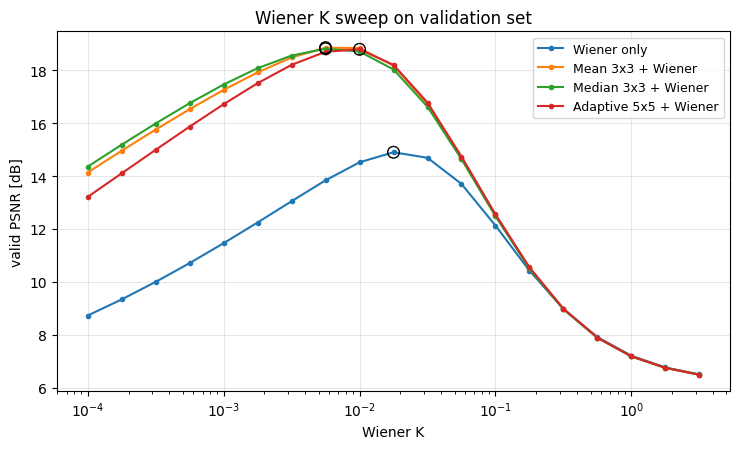

In [9]:
WIENER_K_GRID: list[float] = [float(k) for k in np.logspace(-4, 0.5, 19)]

valid_loader, valid_dataset, valid_len = get_data_wrapper_loader(
    label_split=config.valid_split,
    training_mode=False,
    loader_cfg=LoaderConfig(batch=config.valid_batch, num_workers=4, shuffle=False),
)
print(f"valid images: {valid_len}")


def sweep_wiener_K(
    loader: DataLoader,
    pre: Callable[[Tensor], Tensor],
    k_grid: list[float],
    device: torch.device,
) -> tuple[float, dict[float, float]]:
    """loader 전체에 대해 K 별 평균 PSNR 을 재고, 최대가 되는 K 를 돌려준다."""
    acc: dict[float, list[float]] = {k: [] for k in k_grid}
    with torch.no_grad():
        for _data in loader:
            label = _data[DataKey.Label].to(device, non_blocking=True)
            measure = _data[DataKey.Measure].to(device, non_blocking=True)
            filtered = pre(measure)
            for k in k_grid:
                pred = finalize(wiener_deconv(filtered, K=k))
                acc[k].extend(calculate_psnr(pred, label).flatten().tolist())
    mean_psnr = {k: float(np.mean(v)) for k, v in acc.items()}
    best_k = max(mean_psnr, key=mean_psnr.get)
    return best_k, mean_psnr


BEST_K: dict[str, float] = {}
K_CURVES: dict[str, dict[float, float]] = {}

for _key, _fn in PREFILTERS.items():
    t0 = time.time()
    _best, _curve = sweep_wiener_K(valid_loader, _fn, WIENER_K_GRID, config.device)
    BEST_K[_key] = _best
    K_CURVES[_key] = _curve
    print(f"{PREFILTER_LABEL[_key]:<34} best K = {_best:.4g}  (valid PSNR {_curve[_best]:.3f} dB, {time.time() - t0:.1f}s)")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for _key in PREFILTERS:
    _curve = K_CURVES[_key]
    ax.semilogx(list(_curve.keys()), list(_curve.values()), marker="o", ms=3, label=PREFILTER_LABEL[_key])
    ax.scatter([BEST_K[_key]], [_curve[BEST_K[_key]]], s=70, zorder=5, facecolors="none", edgecolors="k")
ax.set_xlabel("Wiener K")
ax.set_ylabel("valid PSNR [dB]")
ax.set_title("Wiener K sweep on validation set")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 3-2. Test set 에서 conventional methods results (비교 기준용)

In [10]:
def conventional_predict(measure: Tensor) -> dict[str, Tensor]:
    """튜닝된 K 로 conventional 결과를 한 번에 만든다."""
    out = {"measure": finalize(measure)}
    for key, fn in PREFILTERS.items():
        out[f"conv_{key}"] = finalize(wiener_deconv(fn(measure), K=BEST_K[key]))
    return out


CONV_METHODS: list[str] = ["measure", *[f"conv_{k}" for k in PREFILTERS]]
CONV_LABEL: dict[str, str] = {"measure": "Measure (input)", **{f"conv_{k}": v for k, v in PREFILTER_LABEL.items()}}

conv_rows: list[dict] = []
with torch.no_grad():
    for _data in tqdm(test_loader, desc="conventional", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        measure = _data[DataKey.Measure].to(config.device)
        names = _data[DataKey.Name]

        preds = conventional_predict(measure)
        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i], "noise_type": TEST_NOISE_META.get(names[i], {}).get("noise_type", "unknown")}
            for key in CONV_METHODS:
                p = preds[key][i : i + 1]
                row[f"psnr_{key}"] = calculate_psnr(p, lab_i).item()
                row[f"ssim_{key}"] = calculate_ssim(p, lab_i).item()
            conv_rows.append(row)


def print_metric_table(rows: list[dict], methods: list[str], labels: dict[str, str], width: int = 34) -> None:
    print(f"{'method':<{width}}{'n':>5}{'PSNR':>10}{'+-':>9}{'SSIM':>10}{'+-':>9}")
    print("-" * (width + 43))
    for key in methods:
        psnr = [r[f"psnr_{key}"] for r in rows]
        ssim = [r[f"ssim_{key}"] for r in rows]
        print(
            f"{labels[key]:<{width}}{len(rows):>5}"
            f"{np.mean(psnr):>10.3f}{np.std(psnr, ddof=1):>9.3f}"
            f"{np.mean(ssim):>10.4f}{np.std(ssim, ddof=1):>9.4f}"
        )


print()
print_metric_table(conv_rows, CONV_METHODS, CONV_LABEL)

conventional:   0%|          | 0/25 [00:00<?, ?batch/s]


method                                n      PSNR       +-      SSIM       +-
-----------------------------------------------------------------------------
Measure (input)                     100     8.161    2.002   -0.0143   0.1460
Wiener only                         100    15.228    3.965    0.4146   0.2540
Mean 3x3 + Wiener                   100    19.256    4.186    0.5296   0.2134
Median 3x3 + Wiener                 100    19.288    5.029    0.5453   0.2553
Adaptive 5x5 + Wiener               100    19.088    3.721    0.5512   0.2053


In [11]:
# 대표 sample 하나로 conventional 결과를 눈으로 확인한다
_label, _measure, _blur, _noisy_label, _name = test_dataset[SAMPLE_IDX]
_lab_t = _label[None].to(config.device)
_mea_t = _measure[None].to(config.device)
with torch.no_grad():
    _preds = conventional_predict(_mea_t)

lab = _lab_t.cpu().numpy().squeeze()
n_col = 1 + len(CONV_METHODS)
fig, axes = plt.subplots(2, n_col, figsize=(3.2 * n_col, 7.4))
axes[0, 0].imshow(lab, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Label", fontsize=10)
axes[0, 0].axis("off")
axes[1, 0].axis("off")

for c, key in enumerate(CONV_METHODS):
    img = _preds[key].cpu().numpy().squeeze()
    p = calculate_psnr(_preds[key], _lab_t).item()
    s = calculate_ssim(_preds[key], _lab_t).item()
    err = np.abs(img - lab)
    axes[0, c + 1].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, c + 1].set_title(f"{CONV_LABEL[key]}\nPSNR {p:.2f} / SSIM {s:.4f}", fontsize=9)
    axes[0, c + 1].axis("off")
    im = axes[1, c + 1].imshow(err, cmap="magma", vmin=0, vmax=0.3)
    axes[1, c + 1].set_title(f"|error| max {err.max():.3f}", fontsize=9)
    axes[1, c + 1].axis("off")
fig.colorbar(im, ax=axes[1, -1], fraction=0.046, pad=0.02)
fig.suptitle(f"Conventional restoration | {_name} | noise={TEST_NOISE_META.get(_name, {}).get('noise_type', '?')}", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 4. Methods using network

공식 백본 정의 (U-Net / DnCNN). 이 트랙이 학습하는 것은 **U-Net 하나** (measure → clean 직행).
Restormer 로 바꾸려면 `SPECS["n2n_mc"].build` 의 `Unet(...)` 한 줄만 교체하면 된다.

In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_chans: int, out_chans: int) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.layers(x)


def create_down_sample_layers(in_chans: int, chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList([ConvBlock(in_chans, chans)])
    ch = chans
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch, ch * 2))
        ch *= 2
    return layers


def create_up_sample_layers(chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList()
    ch = chans * (2 ** (num_pool_layers - 1))
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch * 2, ch // 2))
        ch //= 2
    layers.append(ConvBlock(ch * 2, ch))
    return layers


class Unet(nn.Module):
    def __init__(self, in_chans: int = 1, out_chans: int = 1, chans: int = 32, num_pool_layers: int = 4) -> None:
        super().__init__()
        self.in_chans = in_chans
        self.out_chans = out_chans
        self.num_pool_layers = num_pool_layers

        self.down_sample_layers = create_down_sample_layers(in_chans, chans, num_pool_layers)
        self.bottleneck_conv = ConvBlock(chans * (2 ** (num_pool_layers - 1)), chans * (2 ** (num_pool_layers - 1)))
        self.up_sample_layers = create_up_sample_layers(chans, num_pool_layers)
        self.final_conv = nn.Sequential(
            nn.Conv2d(chans, chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(chans, out_chans, kernel_size=1, padding=0),
        )

    def forward(self, x: Tensor) -> Tensor:
        stack = []
        output = x
        for layer in self.down_sample_layers:
            output = layer(output)
            stack.append(output)
            output = functional.max_pool2d(output, kernel_size=2)

        output = self.bottleneck_conv(output)

        for layer in self.up_sample_layers:
            downsampled_output = stack.pop()
            output = functional.interpolate(
                output, size=downsampled_output.shape[-2:], mode="bilinear", align_corners=False
            )
            output = torch.cat([output, downsampled_output], dim=1)
            output = layer(output)

        return self.final_conv(output)


class DnCNN(nn.Module):
    def __init__(self, channels: int, num_of_layers: int, kernel_size: int, padding: int, features: int) -> None:
        super().__init__()
        layers: list[nn.Module] = [
            nn.Conv2d(channels, features, kernel_size=kernel_size, padding=padding, bias=False),
            nn.SiLU(inplace=True),
        ]
        for _ in range(num_of_layers - 1):
            layers += [
                nn.Conv2d(features, features, kernel_size=kernel_size, padding=padding, bias=False),
                nn.GroupNorm(4, features),
                nn.SiLU(inplace=True),
            ]
        layers.append(nn.Conv2d(features, channels, kernel_size=kernel_size, padding=padding, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        if x.dim() != 4:
            raise ValueError(f"Input tensor must be 4D, but got {x.dim()}D tensor.")
        return x + self.dncnn(x)

## 4-1. [보충] 핵심 loss — N2N through A + TV

```
loss = | A( f(y1) ) − y2 |₁   +   λ · TV( f(y1) )
```

**항 1 (물리 일치 + 노이즈 배제)** : f(y1) 이 진짜 clean 에 가깝다면, 다시 dipole 을 걸었을 때
A(f(y1)) ≈ Ax ≈ "y2 의 노이즈 없는 부분" 이 되어 loss 가 작아진다.
- deconv 는 **A 가 가르친다** (커널을 아니까 가능)
- 타깃 y2 의 노이즈는 입력 y1 과 독립이라 **맞히려야 맞힐 수 없다** → 노이즈 쪽으로는 수렴 불가
  → 자연히 노이즈를 버리고 신호만 남기는 법을 배운다 (Noise2Noise 원리)
- L1(절댓값) 을 쓰는 이유: L1 은 "중앙값" 으로 수렴 → salt & pepper 처럼
  일부 픽셀만 극단값으로 바뀌는 노이즈가 타깃에 섞여 있어도 학습이 오염되지 않는다

**항 2 (TV, 사각지대 메우기)** : dipole 커널은 특정 주파수(cone)를 거의 0 으로 죽인다.
그 주파수에 f 가 무엇을 넣든 A 를 통과하면 사라져서 **항 1이 채점하지 못한다.**
채점 안 되는 곳에는 줄무늬 아티팩트가 생기기 쉬우므로,
"이미지는 이유 없이 울퉁불퉁하면 안 된다"(이웃 픽셀 차이의 합 = Total Variation) 는
상식 점수를 추가해 그 빈칸을 자연스럽게 채우게 한다.
- supervised 트랙에서는 clean 정답이 이 빈칸을 채점해 준다. 우리는 정답이 없으므로 TV 로 대체.

**λ (LAMBDA_TV) 튜닝 가이드** : 결과에 줄무늬/얼룩이 남으면 ↑, 만화처럼 뭉개지면 ↓.
val PSNR 로 몇 개 값을 짧게 비교해 정하면 된다 (튜닝 대상 스칼라는 이것 하나).

In [13]:
LAMBDA_TV: float = 0.05  # TV 항 가중치. 줄무늬 남으면 키우고, 과하게 뭉개지면 줄인다

l1_loss = torch.nn.L1Loss()


def tv_loss(x: Tensor) -> Tensor:
    """Total Variation: 이웃 픽셀 차이(절댓값)의 평균. 낮을수록 매끈한 이미지."""
    dh = (x[..., 1:, :] - x[..., :-1, :]).abs().mean()
    dw = (x[..., :, 1:] - x[..., :, :-1]).abs().mean()
    return dh + dw


def n2n_mc_loss(model: nn.Module, d: dict) -> Tensor:
    """label 은 전혀 사용하지 않는다. (measure=y1, noisy_label=y2 슬롯 재활용)"""
    y1, y2 = d["measure"], d["noisy_label"]
    x_hat = model(y1)                       # 복원 추정
    loss_dc = l1_loss(dipole_forward(x_hat), y2)  # 다시 blur 시켜 독립 관측과 비교
    return loss_dc + LAMBDA_TV * tv_loss(x_hat)


# 자가 점검: loss 가 스칼라이고 gradient 가 흐르는지
_m = nn.Conv2d(1, 1, 3, padding=1)
_d = {"measure": torch.rand(2, 1, 64, 64), "noisy_label": torch.rand(2, 1, 64, 64)}
_loss = n2n_mc_loss(_m, _d)
_loss.backward()
assert _loss.dim() == 0 and _m.weight.grad is not None
print(f"loss self-test OK | loss {_loss.item():.4f} | TV(rand) {tv_loss(_d['measure']).item():.4f}")

loss self-test OK | loss 0.4553 | TV(rand) 0.6760


## 5. 학습

## 5-0. [보충] `train_model` / `SPECS`

다른 트랙과 같은 학습 루프에 `spec.paired=True` 하나만 더했다:
학습 dataset 의 시뮬레이터를 `PairedDegradationSimulator` (노이즈 쌍 생성) 로 바꾼다.
val/test 는 공식 시뮬레이터 그대로 (y2 필요 없음 — 추론은 `f(measure)` 한 번이면 끝).

학습 중 val PSNR 은 **최종 파이프라인 그대로** (`finalize(f(measure))` vs label) 측정하므로
epoch 별 숫자가 곧 최종 성능의 추이다. 후처리 튜닝 단계가 아예 없다.

In [14]:
@dataclass
class Spec:
    name: str
    build: Callable[[], nn.Module]
    loss_fn: Callable  # (model, data_on_device) -> scalar loss
    predict: Callable  # (model, measure) -> 복원 결과 (val/test 공용, finalize 포함)
    epochs: int
    batch: int
    lr: float
    paired: bool = False  # True 면 학습 데이터를 (y1, y2) 노이즈 쌍으로 생성


def _to_device(_data):
    return {
        "label": _data[DataKey.Label].to(config.device, non_blocking=True),
        "measure": _data[DataKey.Measure].to(config.device, non_blocking=True),
        "blur": _data[DataKey.Blur].to(config.device, non_blocking=True),
        "noisy_label": _data[DataKey.NoisyLabel].to(config.device, non_blocking=True),
    }


def evaluate_predict(predict: Callable, model: nn.Module, loader: DataLoader) -> float:
    psnrs = []
    with torch.no_grad():
        for _data in loader:
            d = _to_device(_data)
            pred = predict(model, d["measure"])
            psnrs.extend(calculate_psnr(pred, d["label"]).flatten().tolist())
    return float(np.mean(psnrs))


def train_model(spec: Spec) -> dict:
    run_dir = config.run_dir / spec.name
    os.makedirs(run_dir, exist_ok=True)

    model = spec.build().to(config.device)
    optim = torch.optim.AdamW(model.parameters(), lr=spec.lr, betas=(0.9, 0.99))

    train_loader, train_dataset, train_len = get_data_wrapper_loader(
        label_split=config.train_split,
        training_mode=True,
        loader_cfg=LoaderConfig(batch=spec.batch, num_workers=config.num_workers, shuffle=True),
    )
    if spec.paired:
        train_dataset.degrade = PairedDegradationSimulator()  # (y1, y2) 쌍 생성으로 교체
    print(f"[{spec.name}] params {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M | "
          f"train {train_len} | epochs {spec.epochs} | batch {spec.batch} | lr {spec.lr:g} | "
          f"paired={spec.paired} | lambda_tv={LAMBDA_TV}")

    best_psnr, history = -1.0, []
    for epoch in range(spec.epochs):
        model.train()
        losses = []
        for _data in tqdm(train_loader, desc=f"{spec.name} ep {epoch + 1}/{spec.epochs}", leave=False):
            optim.zero_grad()
            loss = spec.loss_fn(model, _to_device(_data))
            loss.backward()
            optim.step()
            losses.append(loss.item())

        model.eval()
        val_psnr = evaluate_predict(spec.predict, model, valid_loader)
        history.append({"epoch": epoch + 1, "loss": float(np.mean(losses)), "val_psnr": val_psnr})
        star = ""
        if val_psnr > best_psnr:
            best_psnr = val_psnr
            torch.save(model.state_dict(), run_dir / "best.ckpt")
            star = "  <- best"
        print(f"[{spec.name}] ep {epoch + 1}: loss {np.mean(losses):.4f} | val PSNR {val_psnr:.3f}{star}")

    model.load_state_dict(torch.load(run_dir / "best.ckpt", map_location=config.device, weights_only=True))
    with open(run_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2)
    print(f"[{spec.name}] best val PSNR {best_psnr:.3f} | ckpt: {run_dir / 'best.ckpt'}")
    return {"model": model.eval(), "spec": spec, "best_val_psnr": best_psnr, "history": history}


SPECS: dict[str, Spec] = {
    "n2n_mc": Spec(
        name="n2n_mc",
        # 백본 교체 지점: Restormer 로 바꾸려면 이 한 줄만 갈아끼우면 된다
        build=lambda: Unet(in_chans=1, out_chans=1, chans=64, num_pool_layers=4),
        loss_fn=n2n_mc_loss,
        predict=lambda m, x: finalize(m(x)),  # 추론은 f 한 번. 후처리 없음
        epochs=30, batch=16, lr=3e-4,  # T4 기준. A100 이면 batch 64 / lr 1e-3
        paired=True,
    ),
}

RESULTS: dict[str, dict] = {}

### (참고) A. U-Net e2e / B. DnCNN 트랙 — 이 노트북에서는 실행하지 않음

example 노트북의 A/B 학습 호출. 이 트랙과 무관하므로 raw 셀로 바꿔 두어 Run All 시 실행되지 않는다.

### C. [보충] one-stage 학습 — 체크포인트 자동 이어걷기

`logs_n2n/n2n_mc*/best.ckpt` 중 가장 최근 것에서 이어서 학습하고, 없으면 처음부터.
실행마다 새 폴더(`n2n_mc_rNN`)에 저장해 이전 best 를 덮어쓰지 않는다.
→ T4 에서 돌리다 중단하고 A100 에서 이 셀을 다시 실행하면 그대로 이어진다.

- val PSNR 이 3~5 epoch 정체면 수동 중단 OK (best 는 저장되어 있음)
- OOM 이면 batch 를 절반으로 (lr 도 절반 권장)
- **λ 실험 팁**: LAMBDA_TV 를 바꿔 짧게(5 epoch 정도) 돌려 val PSNR 을 비교하면 된다.
  λ 를 바꾼 실험은 새 폴더에 저장되므로 이어걷기가 섞이지 않게 폴더명을 확인할 것

In [15]:
# ---- one-stage 학습: 체크포인트 자동 이어걷기 ----
N2N_EPOCHS = 30   # 상한. val PSNR 정체 시 수동 중단 OK
N2N_BATCH = 64    # T4 16GB 기준. A100 이면 64
N2N_LR = 1e-3     # batch 16 기준. batch 64 면 1e-3 정도로

_prev = sorted(config.run_dir.glob("n2n_mc*/best.ckpt"), key=lambda p: p.stat().st_mtime)
_resume_from = _prev[-1] if _prev else None


def _build_n2n():
    m = SPECS["n2n_mc"].build()
    if _resume_from is not None:
        m.load_state_dict(torch.load(str(_resume_from), map_location="cpu", weights_only=True))
    return m


_run_name = f"n2n_mc_r{len(_prev):02d}"
print("시작점:", _resume_from if _resume_from else "처음부터 (random init)")
print("이번 실행 저장 폴더:", config.run_dir / _run_name)

n2n_spec = Spec(**{**SPECS["n2n_mc"].__dict__,
                   "name": _run_name,
                   "build": _build_n2n,
                   "epochs": N2N_EPOCHS,
                   "batch": N2N_BATCH,
                   "lr": N2N_LR})
RESULTS["n2n_mc"] = train_model(n2n_spec)

시작점: /content/drive/MyDrive/플젝5/logs_n2n/n2n_mc_r00/best.ckpt
이번 실행 저장 폴더: /content/drive/MyDrive/플젝5/logs_n2n/n2n_mc_r01
[n2n_mc_r01] params 13.43 M | train 7268 | epochs 30 | batch 64 | lr 0.001 | paired=True | lambda_tv=0.05


n2n_mc_r01 ep 1/30:   0%|          | 0/114 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cdfaff16660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7cdfaff16660>    
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'

AssertionError  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
:     can only test a child processif w.is_alive():

  File "/usr/lib/

[n2n_mc_r01] ep 1: loss 0.0633 | val PSNR 18.375  <- best


n2n_mc_r01 ep 2/30:   0%|          | 0/114 [00:00<?, ?it/s]

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cdfaff16660><function _MultiProcessingDataLoaderIter.__del__ at 0x7cdfaff16660>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():
if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only te

[n2n_mc_r01] ep 29: loss 0.0516 | val PSNR 22.737


n2n_mc_r01 ep 30/30:   0%|          | 0/114 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cdfaff16660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cdfaff16660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

[n2n_mc_r01] ep 30: loss 0.0516 | val PSNR 22.617
[n2n_mc_r01] best val PSNR 22.823 | ckpt: /content/drive/MyDrive/플젝5/logs_n2n/n2n_mc_r01/best.ckpt


### 5-2. [보충] 학습이 원리대로 작동하는지 중간 점검

loss 의 두 주장 — "A(f(y1)) 은 y2 의 신호 부분과 같아져야 한다", "f(y1) 은 clean 에 가까워야 한다" —
을 눈으로 확인한다. validation 이미지 하나에 노이즈 쌍을 만들어:

- `f(y1)` vs `label` : 최종 복원 품질 (줄무늬 아티팩트가 보이면 LAMBDA_TV ↑)
- `A(f(y1))` vs `blur(Ax)` : 물리 일치 항이 제대로 작동하는지
- `A(f(y1))` 에 노이즈가 없어야 정상 (노이즈까지 복원했다면 N2N 이 실패한 것)

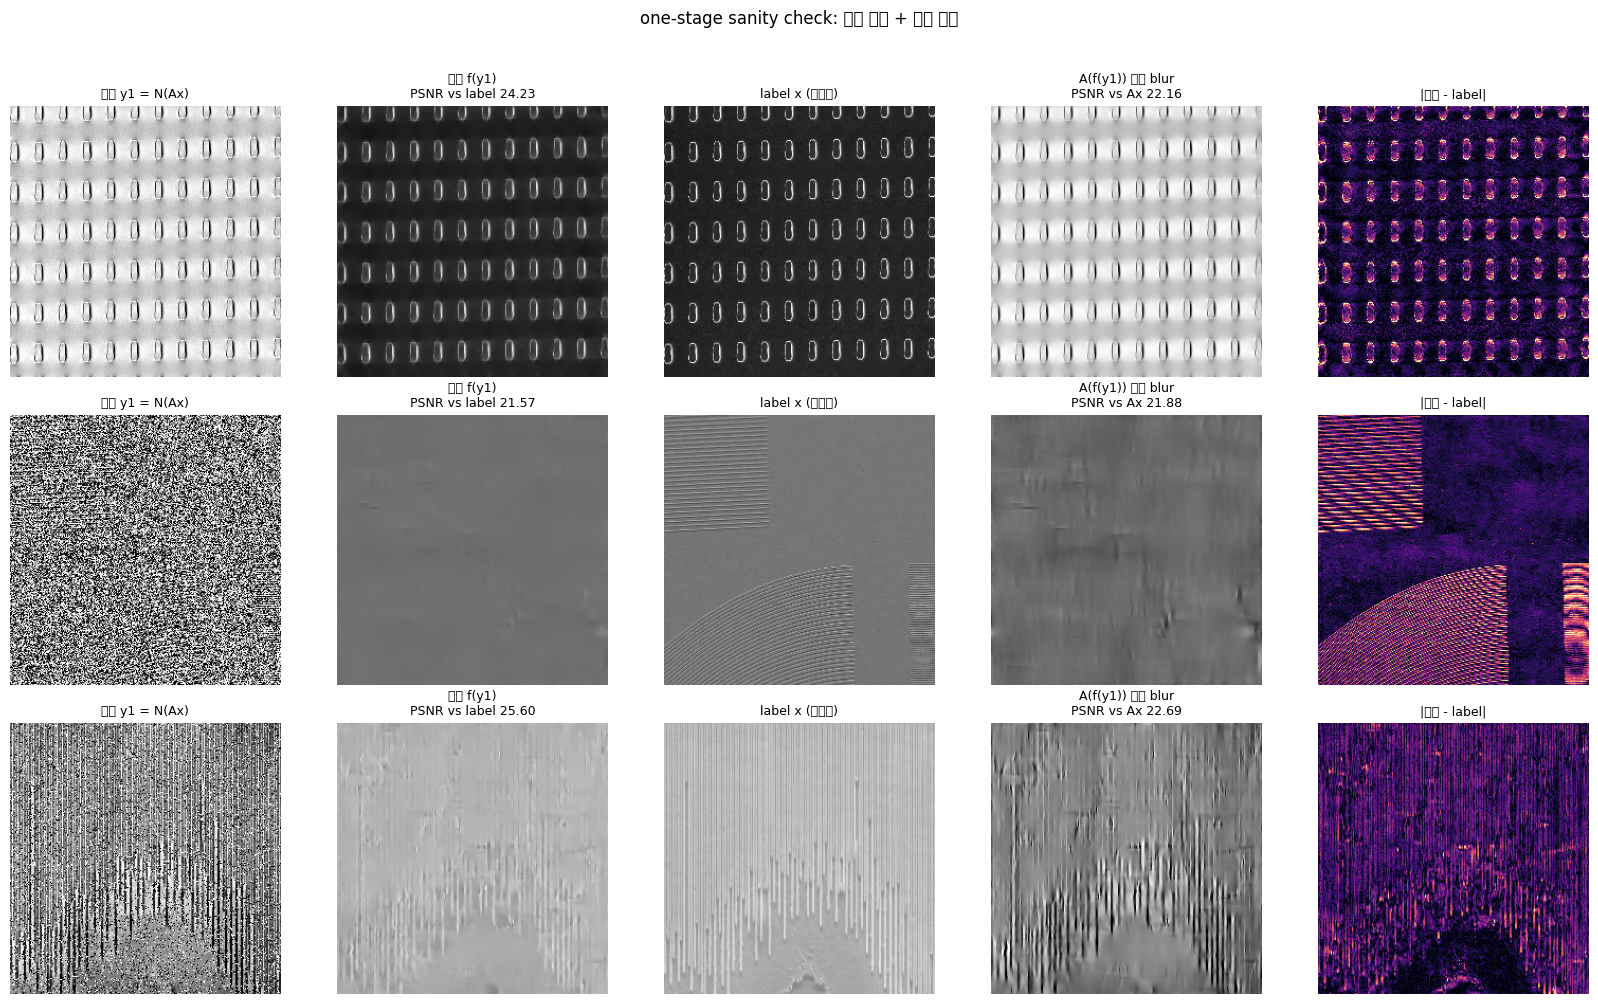

In [16]:
_model = RESULTS["n2n_mc"]["model"]
_val_data = next(iter(valid_loader))
_lab = _val_data[DataKey.Label].to(config.device)
_blur_v = _val_data[DataKey.Blur].to(config.device)
_sim_pair = PairedDegradationSimulator()
_y1 = torch.stack([_sim_pair.noise(_blur_v[i].cpu()) for i in range(_blur_v.shape[0])]).to(config.device)

with torch.no_grad():
    _xhat = finalize(_model(_y1))
    _re_blur = dipole_forward(_xhat)

_n_show = min(3, _lab.shape[0])
fig, axes = plt.subplots(_n_show, 5, figsize=(16.5, 3.4 * _n_show))
axes = np.atleast_2d(axes)
for i in range(_n_show):
    _p = calculate_psnr(_xhat[i:i + 1], _lab[i:i + 1]).item()
    _pb = calculate_psnr(_re_blur[i:i + 1], _blur_v[i:i + 1]).item()
    _bn = _blur_v[i, 0].cpu().numpy()
    _vmin, _vmax = np.percentile(_bn, 1), np.percentile(_bn, 99)
    axes[i, 0].imshow(_y1[i, 0].cpu().numpy(), cmap="gray", vmin=_vmin, vmax=_vmax)
    axes[i, 0].set_title("입력 y1 = N(Ax)", fontsize=9)
    axes[i, 1].imshow(_xhat[i, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title(f"복원 f(y1)\nPSNR vs label {_p:.2f}", fontsize=9)
    axes[i, 2].imshow(_lab[i, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[i, 2].set_title("label x (참고용)", fontsize=9)
    axes[i, 3].imshow(_re_blur[i, 0].cpu().numpy(), cmap="gray", vmin=_vmin, vmax=_vmax)
    axes[i, 3].set_title(f"A(f(y1)) 다시 blur\nPSNR vs Ax {_pb:.2f}", fontsize=9)
    axes[i, 4].imshow(np.abs(_xhat[i, 0].cpu().numpy() - _lab[i, 0].cpu().numpy()), cmap="magma", vmin=0, vmax=0.2)
    axes[i, 4].set_title("|복원 - label|", fontsize=9)
    for ax in axes[i]:
        ax.axis("off")
fig.suptitle("one-stage sanity check: 복원 품질 + 물리 일치")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 6. [보충] Test set 통합 평가

conventional baseline 과 우리 트랙을 같은 표에서 비교하고, noise 종류별로 분해한다.
(`noise_meta.json` 은 조교 지시대로 **결과 분석에만** 사용)

- "Wiener only" 대비 개선 폭 = "학습된 복원이 고전 필터보다 낫다"는 실험적 근거 (발표용)
- salt_and_pepper 열이 유독 낮으면 L1 선택을 재검토 (검토 문서 2-6 의 예비안)

In [17]:
NET_LABEL = {"n2n_mc": "One-stage self-sup (N2N+A+TV, label-free)"}

net_rows: list[dict] = []
with torch.no_grad():
    for _data in tqdm(test_loader, desc="network test", unit="batch"):
        d = _to_device(_data)
        names = _data[DataKey.Name]
        preds = {k: r["spec"].predict(r["model"], d["measure"]) for k, r in RESULTS.items()}
        for i in range(d["label"].shape[0]):
            lab_i = d["label"][i: i + 1]
            row = {"file": names[i],
                   "noise_type": TEST_NOISE_META.get(names[i], {}).get("noise_type", "unknown")}
            for k, p in preds.items():
                row[f"psnr_{k}"] = calculate_psnr(p[i: i + 1], lab_i).item()
                row[f"ssim_{k}"] = calculate_ssim(p[i: i + 1], lab_i).item()
            net_rows.append(row)

# ---- 통합 표: conventional + one-stage ----
print()
print_metric_table(conv_rows, CONV_METHODS, CONV_LABEL)
if net_rows:
    print_metric_table(net_rows, list(RESULTS.keys()), NET_LABEL)

# ---- 노이즈 종류별 분해 (S&P 취약 여부 판단) ----
if net_rows:
    _types = ["gaussian", "rician", "uniform", "salt_and_pepper"]
    print()
    print(f"{'method':<40}" + "".join(f"{t[:10]:>12}" for t in _types))
    print("-" * (40 + 12 * len(_types)))
    for k in RESULTS:
        vals = []
        for t in _types:
            sub = [r[f"psnr_{k}"] for r in net_rows if r["noise_type"] == t]
            vals.append(np.mean(sub) if sub else float("nan"))
        print(f"{NET_LABEL[k]:<40}" + "".join(f"{v:>12.2f}" for v in vals))

os.makedirs(config.run_dir, exist_ok=True)
with open(config.run_dir / "test_metrics_n2n.json", "w") as f:
    json.dump(net_rows, f, indent=2)
print(f"\nsaved: {config.run_dir / 'test_metrics_n2n.json'}")

network test:   0%|          | 0/25 [00:00<?, ?batch/s]


method                                n      PSNR       +-      SSIM       +-
-----------------------------------------------------------------------------
Measure (input)                     100     8.161    2.002   -0.0143   0.1460
Wiener only                         100    15.228    3.965    0.4146   0.2540
Mean 3x3 + Wiener                   100    19.256    4.186    0.5296   0.2134
Median 3x3 + Wiener                 100    19.288    5.029    0.5453   0.2553
Adaptive 5x5 + Wiener               100    19.088    3.721    0.5512   0.2053
method                                n      PSNR       +-      SSIM       +-
-----------------------------------------------------------------------------
One-stage self-sup (N2N+A+TV, label-free)  100    23.443    4.347    0.7733   0.1521

method                                      gaussian      rician     uniform  salt_and_p
----------------------------------------------------------------------------------------
One-stage self-sup (N2N+A+TV, lab

### 6-1. [보충] 시각화 — before / after / difference map

test 샘플의 입력 / 복원 / |오차| 를 나란히 본다. (zoom 영역은 `ZOOM` 으로 조정)

In [18]:
N_SHOW = 3
ZOOM = (slice(80, 160), slice(80, 160))  # zoom-in 영역 (원하는 곳으로 조정)

_data = next(iter(test_loader))
d = _to_device(_data)
names = _data[DataKey.Name]

with torch.no_grad():
    preds = {k: r["spec"].predict(r["model"], d["measure"]) for k, r in RESULTS.items()}

for i in range(min(N_SHOW, d["label"].shape[0])):
    lab = d["label"][i, 0].cpu().numpy()
    mea = d["measure"][i, 0].cpu().numpy()
    ncol = 3 + 2 * len(preds)
    fig, axes = plt.subplots(1, ncol, figsize=(3.1 * ncol, 3.6))
    axes[0].imshow(lab, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"label\n{names[i][:18]}", fontsize=8)
    axes[1].imshow(mea, cmap="gray", vmin=np.percentile(mea, 1), vmax=np.percentile(mea, 99))
    _nt = TEST_NOISE_META.get(names[i], {}).get("noise_type", "?")
    axes[1].set_title(f"measure ({_nt})", fontsize=8)
    axes[2].imshow(lab[ZOOM], cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("label zoom", fontsize=8)
    c = 3
    for k, p in preds.items():
        out = p[i, 0].cpu().numpy()
        axes[c].imshow(out, cmap="gray", vmin=0, vmax=1)
        _p = calculate_psnr(p[i : i + 1], d["label"][i : i + 1]).item()
        axes[c].set_title(f"{NET_LABEL[k]}\nPSNR {_p:.2f}", fontsize=8)
        axes[c + 1].imshow(np.abs(out - lab), cmap="magma", vmin=0, vmax=0.2)
        axes[c + 1].set_title("|diff|", fontsize=8)
        c += 2
    for ax in axes:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.